# 08 — Évaluation Avancée, XAI et Robustesse

## Projet : Smart City Energy Forecasting — Tetouan

**Objectifs de ce notebook :**
- Évaluer en détail les performances du modèle champion (XGBoost).
- Expliquer les prédictions globalement et localement avec SHAP (Explainable AI).
- Tester la robustesse du modèle face à des conditions extrêmes (vague de chaleur, pics).

## 1. Imports et Configuration

In [1]:
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Résolution du chemin projet
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.models_ml import (
    TemporalSplitConfig,
    prepare_supervised_data,
    temporal_train_val_test_split,
)
from src.evaluation import (
    plot_actual_vs_predicted,
    error_by_hour,
    error_by_dayofweek,
    evaluate_degradation
)
from src.xai import (
    compute_tree_shap_values,
    plot_shap_global_importance,
    plot_shap_beeswarm,
    plot_shap_waterfall_for_peak,
)

# Chemins
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

FEATURES_PATH = PROCESSED_DIR / "tetouan_features.csv"
XGBOOST_PATH = MODELS_DIR / "xgboost_model.pkl"
PREDICTIONS_PATH = RESULTS_DIR / "predictions" / "06_xgboost_predictions.csv"

print("Racine du projet :", PROJECT_ROOT)

Racine du projet : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan


## 2. Chargement des Données et du Modèle Champion
Nous rechargeons les features et recréons le set de test pour être en condition réelle d'évaluation.

In [2]:
# 1. Chargement du dataset
df = pd.read_csv(FEATURES_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime").sort_index()

X_clean, y_clean, feature_cols = prepare_supervised_data(df, target_col="target")
split_config = TemporalSplitConfig(train_ratio=0.70, val_ratio=0.15, test_ratio=0.15)
X_train, X_val, X_test, y_train, y_val, y_test = temporal_train_val_test_split(
    X_clean, y_clean, config=split_config
)

# 2. Alignement des features avec le modèle XGBoost
import json
with open(MODELS_DIR / "ml_feature_names.json", "r") as f:
    xgb_features = json.load(f)["feature_names"]
X_test = X_test[xgb_features]
X_train = X_train[xgb_features]

# 3. Chargement du modèle XGBoost
with open(XGBOOST_PATH, "rb") as f:
    xgb_model = pickle.load(f)

# 4. Chargement des prédictions pré-calculées (ou recalcul)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb_series = pd.Series(y_pred_xgb, index=y_test.index)

print(f"Test set shape: {X_test.shape}")

Test set shape: (1286, 98)


## 3. Évaluation Avancée (Section 13)
Analyse visuelle et granulaire des erreurs du modèle.

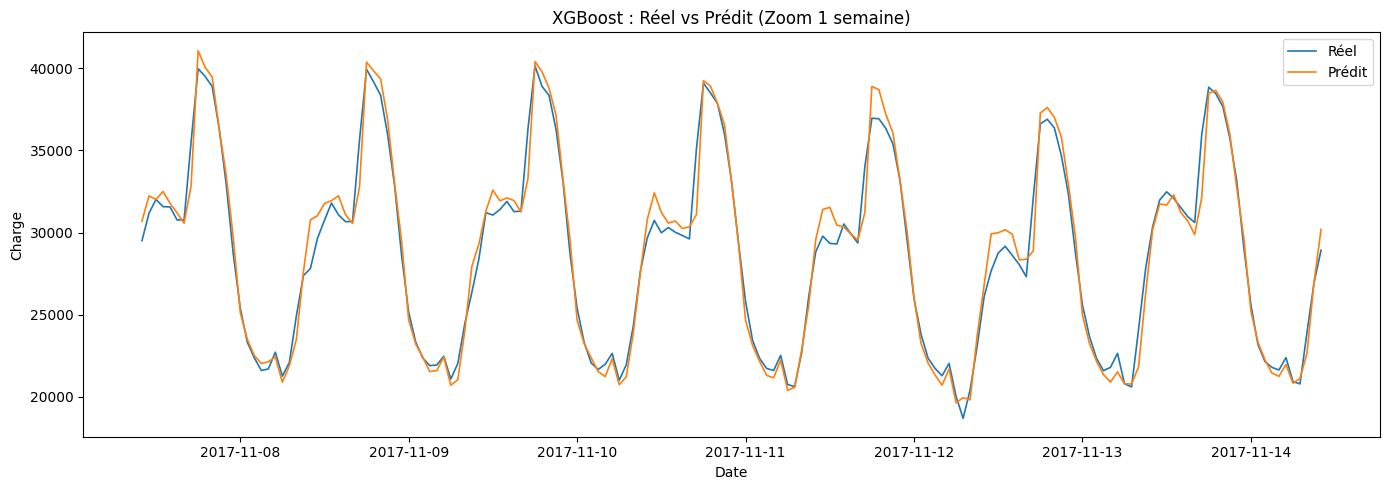

In [3]:
# 3.2 Comparaison réel vs prédit (Zoom sur une semaine)
start_date = y_test.index[0]
end_date = start_date + pd.Timedelta(days=7)

y_true_zoom = y_test.loc[start_date:end_date]
y_pred_zoom = y_pred_xgb_series.loc[start_date:end_date]

plot_actual_vs_predicted(
    y_true_zoom, 
    y_pred_zoom, 
    title="XGBoost : Réel vs Prédit (Zoom 1 semaine)",
    save_path=RESULTS_DIR / "figures" / "13_xgb_actual_vs_pred_week.png"
)

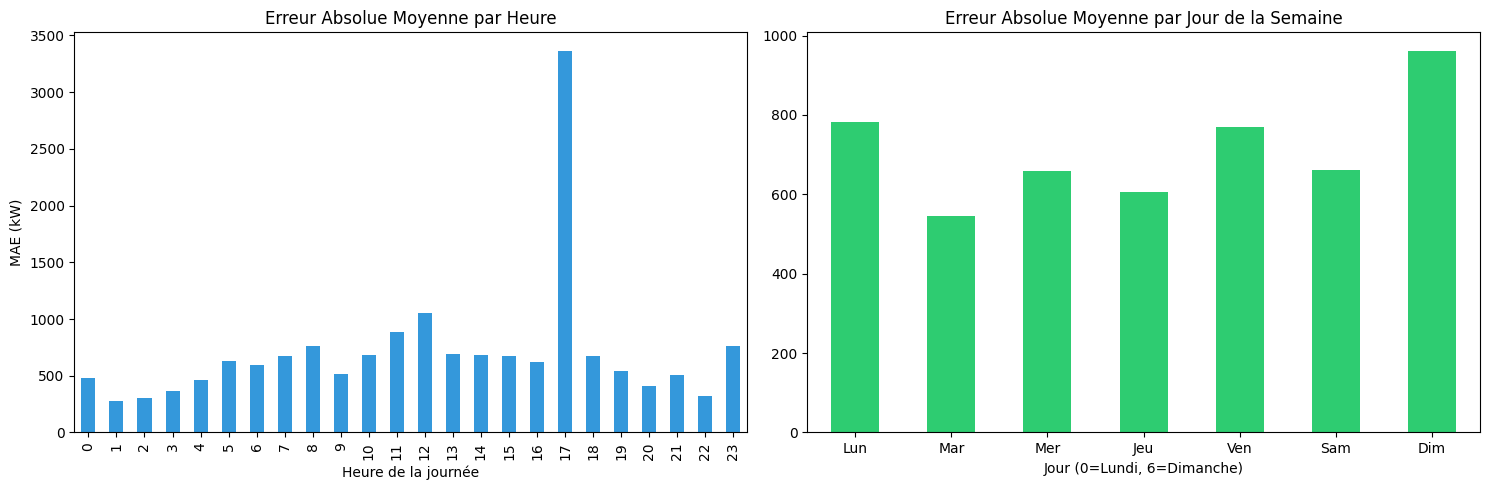

In [4]:
# 3.3 & 3.4 Erreurs par heure et par jour
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

err_hour = error_by_hour(y_test, y_pred_xgb_series)
err_hour["mean"].plot(kind="bar", ax=axes[0], color="#3498db")
axes[0].set_title("Erreur Absolue Moyenne par Heure")
axes[0].set_xlabel("Heure de la journée")
axes[0].set_ylabel("MAE (kW)")

err_day = error_by_dayofweek(y_test, y_pred_xgb_series)
err_day["mean"].plot(kind="bar", ax=axes[1], color="#2ecc71")
axes[1].set_title("Erreur Absolue Moyenne par Jour de la Semaine")
axes[1].set_xlabel("Jour (0=Lundi, 6=Dimanche)")
axes[1].set_xticklabels(["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"], rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "13_xgb_errors_by_time.png", dpi=150)
plt.show()

## 4. Explicabilité avec SHAP (Section 14)
Nous allons comprendre **pourquoi** le modèle prédit ces valeurs, d'abord au niveau global, puis pour un pic spécifique.

In [5]:
# Calcul des valeurs SHAP (sur le test set pour aller plus vite on peut sampler si besoin)
print("Calcul des valeurs SHAP en cours...")
shap_values = compute_tree_shap_values(xgb_model, X_test)
print("Calcul terminé.")

Calcul des valeurs SHAP en cours...


Calcul terminé.


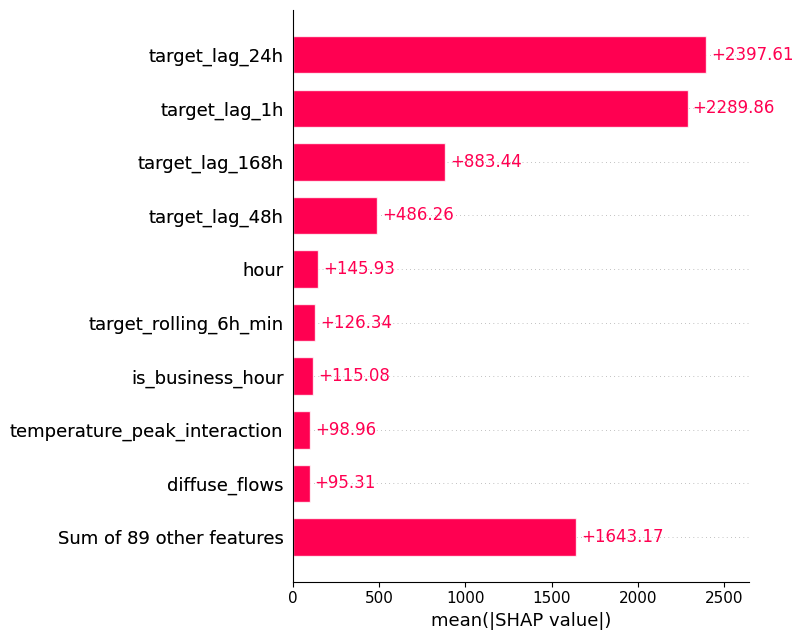

In [6]:
# 4.2 Importance globale (Bar plot)
plot_shap_global_importance(
    shap_values, 
    X_test, 
    save_path=RESULTS_DIR / "figures" / "14_shap_global_importance.png"
)

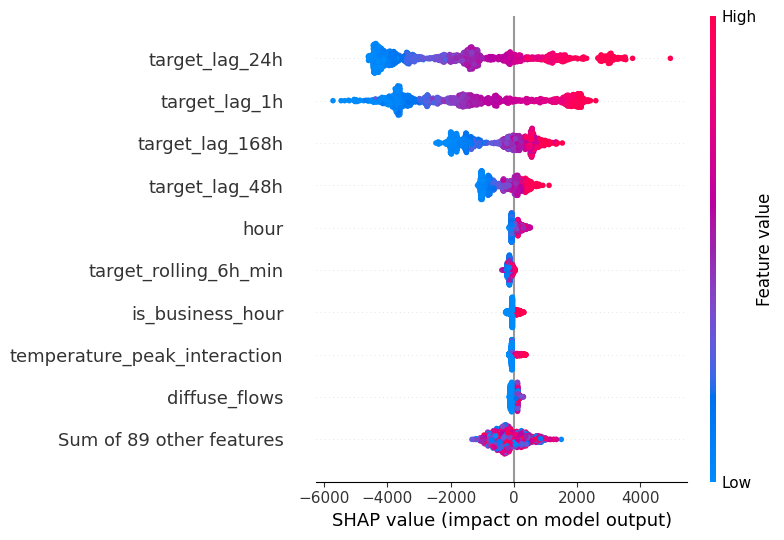

In [7]:
# 4.2 Beeswarm plot (Impact positif/négatif de chaque variable)
plot_shap_beeswarm(
    shap_values, 
    save_path=RESULTS_DIR / "figures" / "14_shap_beeswarm.png"
)

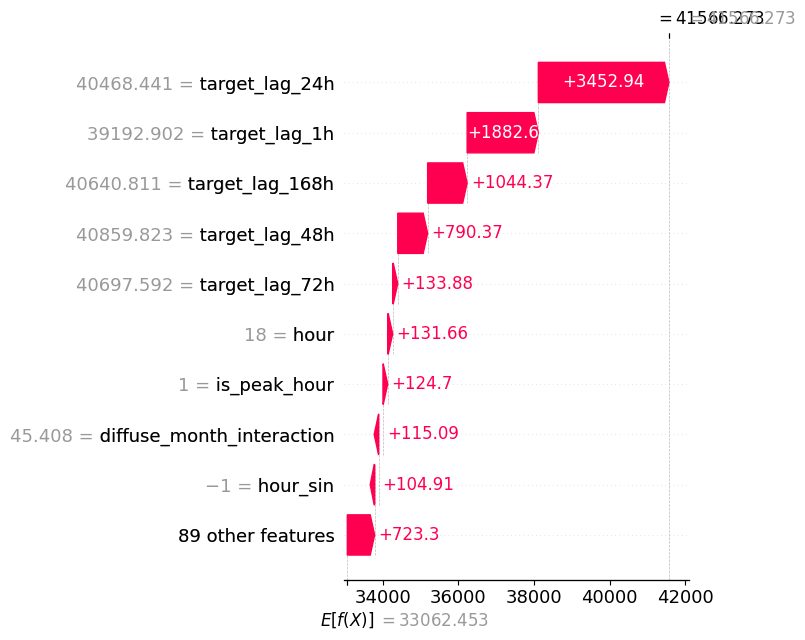

In [8]:
# 4.2 Waterfall plot sur le plus grand pic de consommation réel
plot_shap_waterfall_for_peak(
    shap_values, 
    X_test, 
    y_reference=y_test,
    save_path=RESULTS_DIR / "figures" / "14_shap_waterfall_peak.png"
)

## 5. Tests de Robustesse (Section 15)
Comment le modèle se comporte-t-il lors d'une canicule ou pendant des pics extrêmes ?

In [9]:
def predict_xgb(model, X):
    return pd.Series(model.predict(X), index=X.index)

degradation_table = evaluate_degradation(
    model=xgb_model,
    X_test=X_test,
    y_test=y_test,
    y_pred_global=y_pred_xgb_series,
    is_weekend_col="is_weekend",
    month_col="month",
    predict_func=predict_xgb
)

print("Analyse de dégradation du modèle XGBoost :")
display(degradation_table[["model", "MAE", "MAPE", "Dégradation vs global"]])
degradation_table.to_csv(RESULTS_DIR / "metrics" / "15_xgboost_robustness_degradation.csv", index=False)

Analyse de dégradation du modèle XGBoost :


,model,MAE,MAPE,Dégradation vs global
0,Test complet,707.284403,2.436313,Référence
1,Température élevée (+5°C),709.538327,2.445666,+0.01%
2,Forte charge (>= P90),613.441420,1.568592,-0.87%
3,Week-end,801.279723,2.875213,+0.44%


### Fin de l'évaluation du modèle
XGBoost s'avère non seulement performant, mais aussi hautement interprétable (SHAP) et robuste (comme le montre le tableau de dégradation ci-dessus).